In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import nibabel as nib
import h5py
from scipy.spatial import KDTree, cKDTree
from lameg.surf import interpolate_data
from lameg.viz import show_surface, color_map
import io
from PIL import Image
from base64 import b64decode


In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225, fontsize=26):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=fontsize, va='top', ha='right')


In [4]:
out_dir='../output/wb_simulations'
n_layers=11
win_size=50
snr=-20

In [5]:
# Mesh to use for forward model in the simulations
multilayer_mesh_fname = '/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/multilayer.11.ds.link_vector.fixed.gii'

# Load multilayer mesh and compute the number of vertices per layer
mesh = nib.load(multilayer_mesh_fname)
verts_per_surf = int(mesh.darrays[0].data.shape[0]/n_layers)

pial_orig_mesh = nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/pial.gii')
pial_ds_mesh = nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/pial.ds.gii')

multilayer_vertices = mesh.darrays[0].data
multilayer_faces = mesh.darrays[1].data  # Face indices
multilayer_orientations = mesh.darrays[2].data  # Assuming this is the orientation vectors

pial_vertices = pial_orig_mesh.darrays[0].data  # Vertex coordinates
pial_faces = pial_orig_mesh.darrays[1].data  # Face indices

pial_ds_vertices = pial_ds_mesh.darrays[0].data  # Vertex coordinates
pial_ds_faces = pial_ds_mesh.darrays[1].data  # Face indices

scalp_mesh=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/t1wscalp_2562.surf.gii')
scalp_vertices = scalp_mesh.darrays[1].data  # Vertex coordinates
scalp_faces = scalp_mesh.darrays[0].data  # Face indices

orig_inflated=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/inflated.gii')
ds_inflated=nib.load('/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/inflated.ds.gii')

In [6]:
# Compute surface normals (if not already available)
def compute_normals(vertices, faces):
    normals = np.zeros_like(vertices)
    for i in range(faces.shape[0]):
        v0, v1, v2 = vertices[faces[i]]
        # Edge vectors
        edge1 = v1 - v0
        edge2 = v2 - v0
        # Cross product to get normal
        normal = np.cross(edge1, edge2)
        normal /= np.linalg.norm(normal)  # Normalize the normal
        normals[faces[i]] += normal
    normals /= np.linalg.norm(normals, axis=1)[:, np.newaxis]  # Normalize all normals
    return normals

normals = compute_normals(scalp_vertices, scalp_faces)

 # Build a KD-tree for the downsampled vertices
tree = cKDTree(scalp_vertices) # pylint: disable=not-callable

# Find the nearest neighbor in the downsampled mesh for each vertex in the original mesh
distances, indices = tree.query(pial_ds_vertices)

# Compute the dot product between the orientation and the normal vectors
dot_products = np.abs(np.einsum('ij,ij->i', normals[indices], multilayer_orientations[:verts_per_surf,:])) 

In [7]:
left_side_view=[-150, -25, -28,
                8, 2.5, -32,
                0.25, -0.37, 0.9]

In [8]:
# Plot colors and camera view
# Interpolate for display on the original inflated surface
interpolated_data = interpolate_data(orig_inflated, ds_inflated, dot_products)

c_range = [np.min(interpolated_data), np.max(interpolated_data)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]


# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    0, 
    1,
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [9]:
plot.fetch_screenshot()

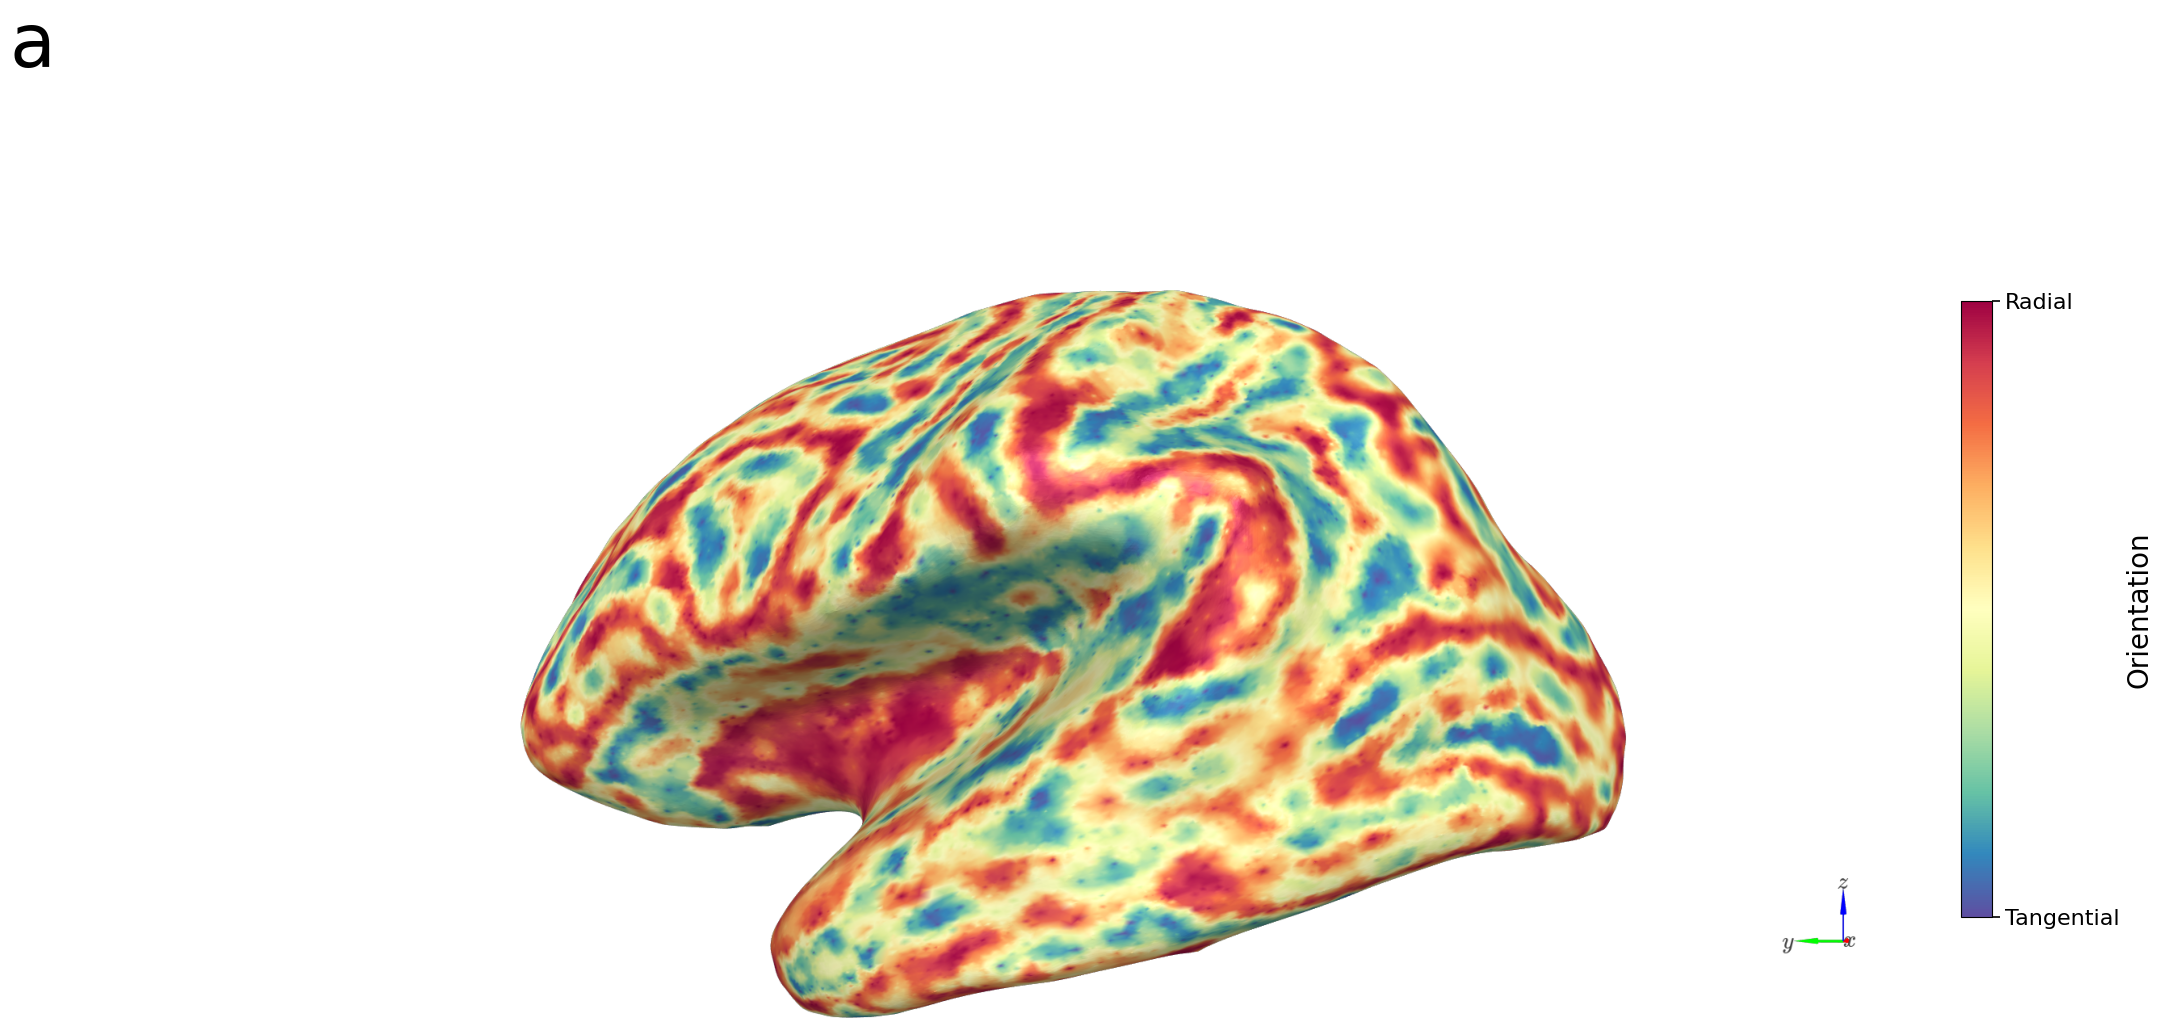

In [11]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Orientation", fontsize=20)

# Set two ticks: at min (vmin) and max (vmax)
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["Tangential", "Radial"])

add_subplot_label(ax, 'a', fontsize=54)

# Show and save figure
plt.savefig(f"figure_07_orientation.pdf")


In [12]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, distances)
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [13]:
plot.fetch_screenshot()

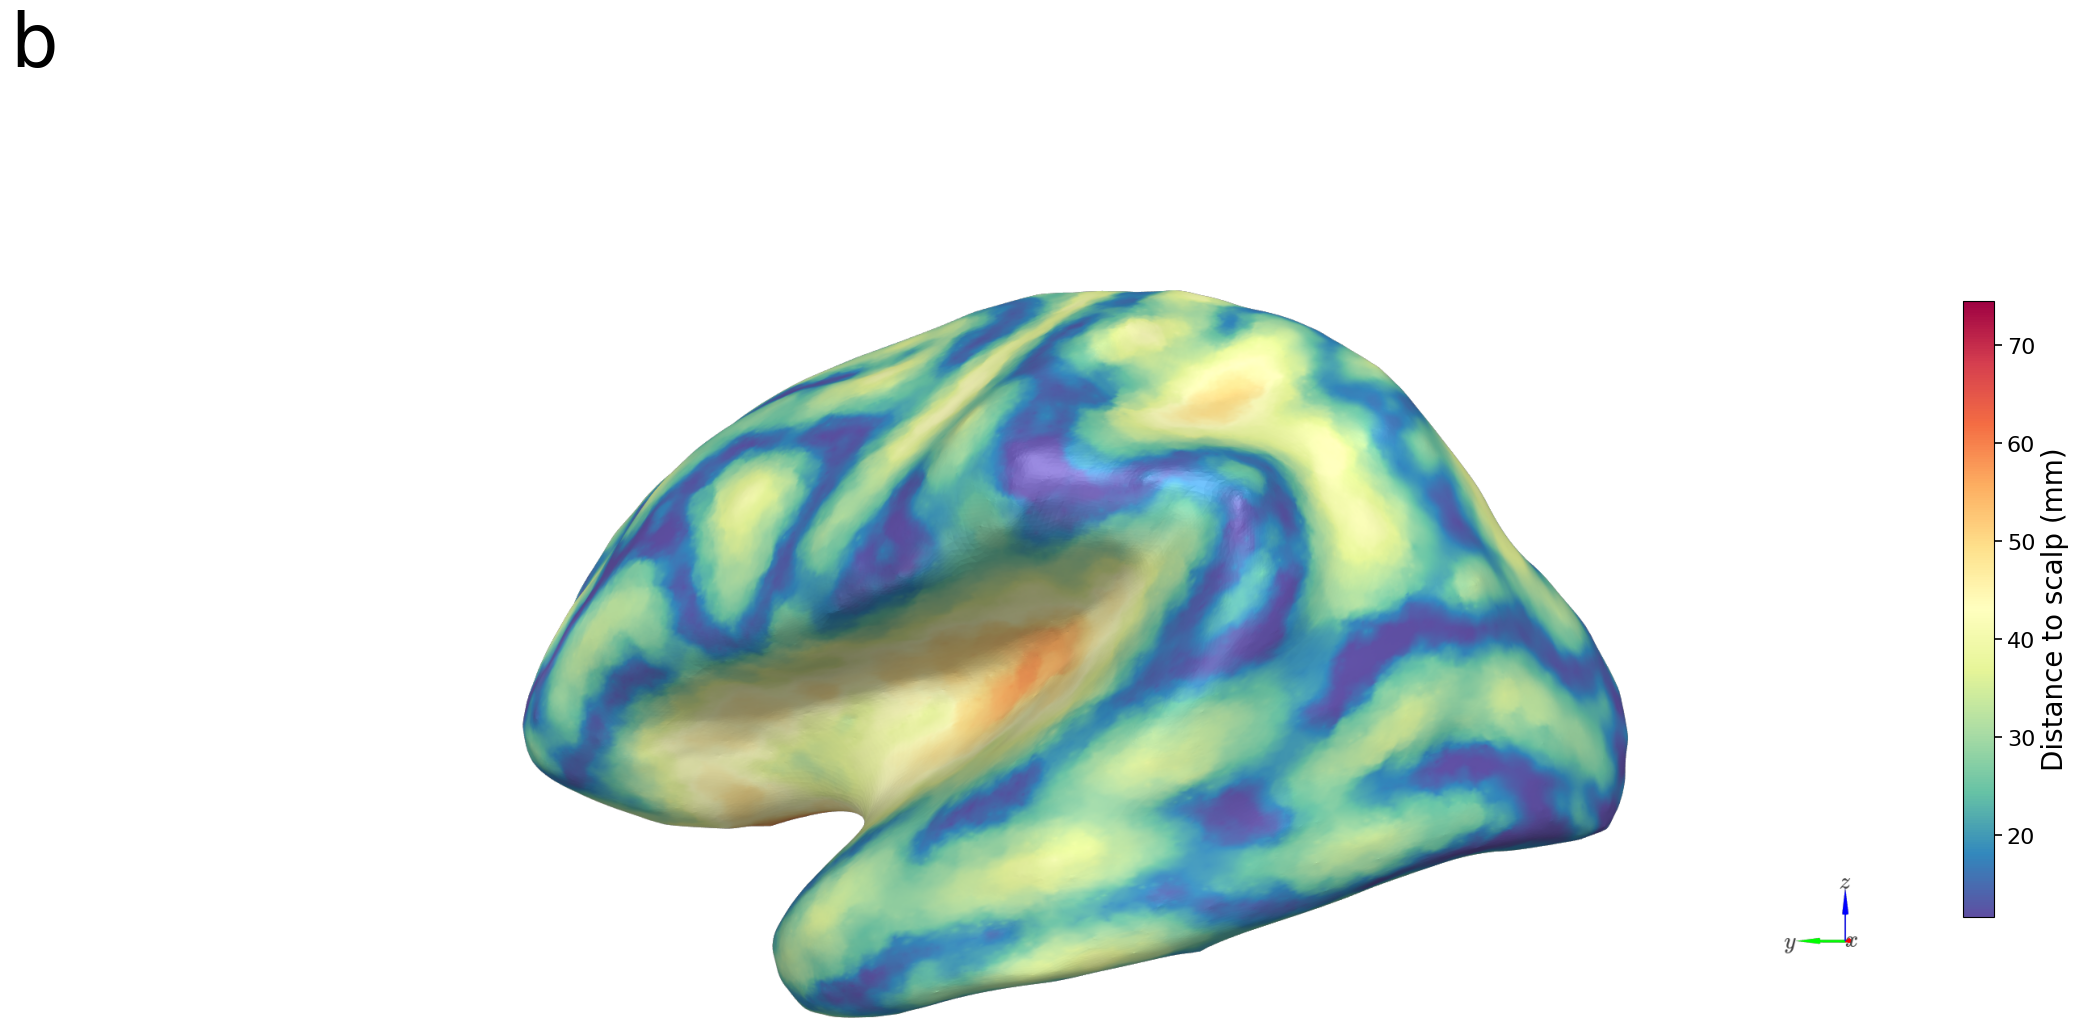

In [15]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Distance to scalp (mm)", fontsize=20)

add_subplot_label(ax, 'b', fontsize=54)

# Show and save figure
plt.savefig(f"figure_07_distance.pdf")


In [8]:
gainmat='../output/wb_simulations/SPMgainmatrix_pcspm_converted_autoreject-sub-001-ses-01-motor-epo_1.mat'
with h5py.File(gainmat,'r') as file:
    lf_mat=file['G'][()]
lf_mat.shape

(320430, 275)

In [9]:
thickness=np.sqrt(np.sum((mesh.darrays[0].data[:verts_per_surf,:]-mesh.darrays[0].data[(n_layers-1)*verts_per_surf:,:])**2,axis=-1))

In [18]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, thickness)
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [19]:
plot.fetch_screenshot()

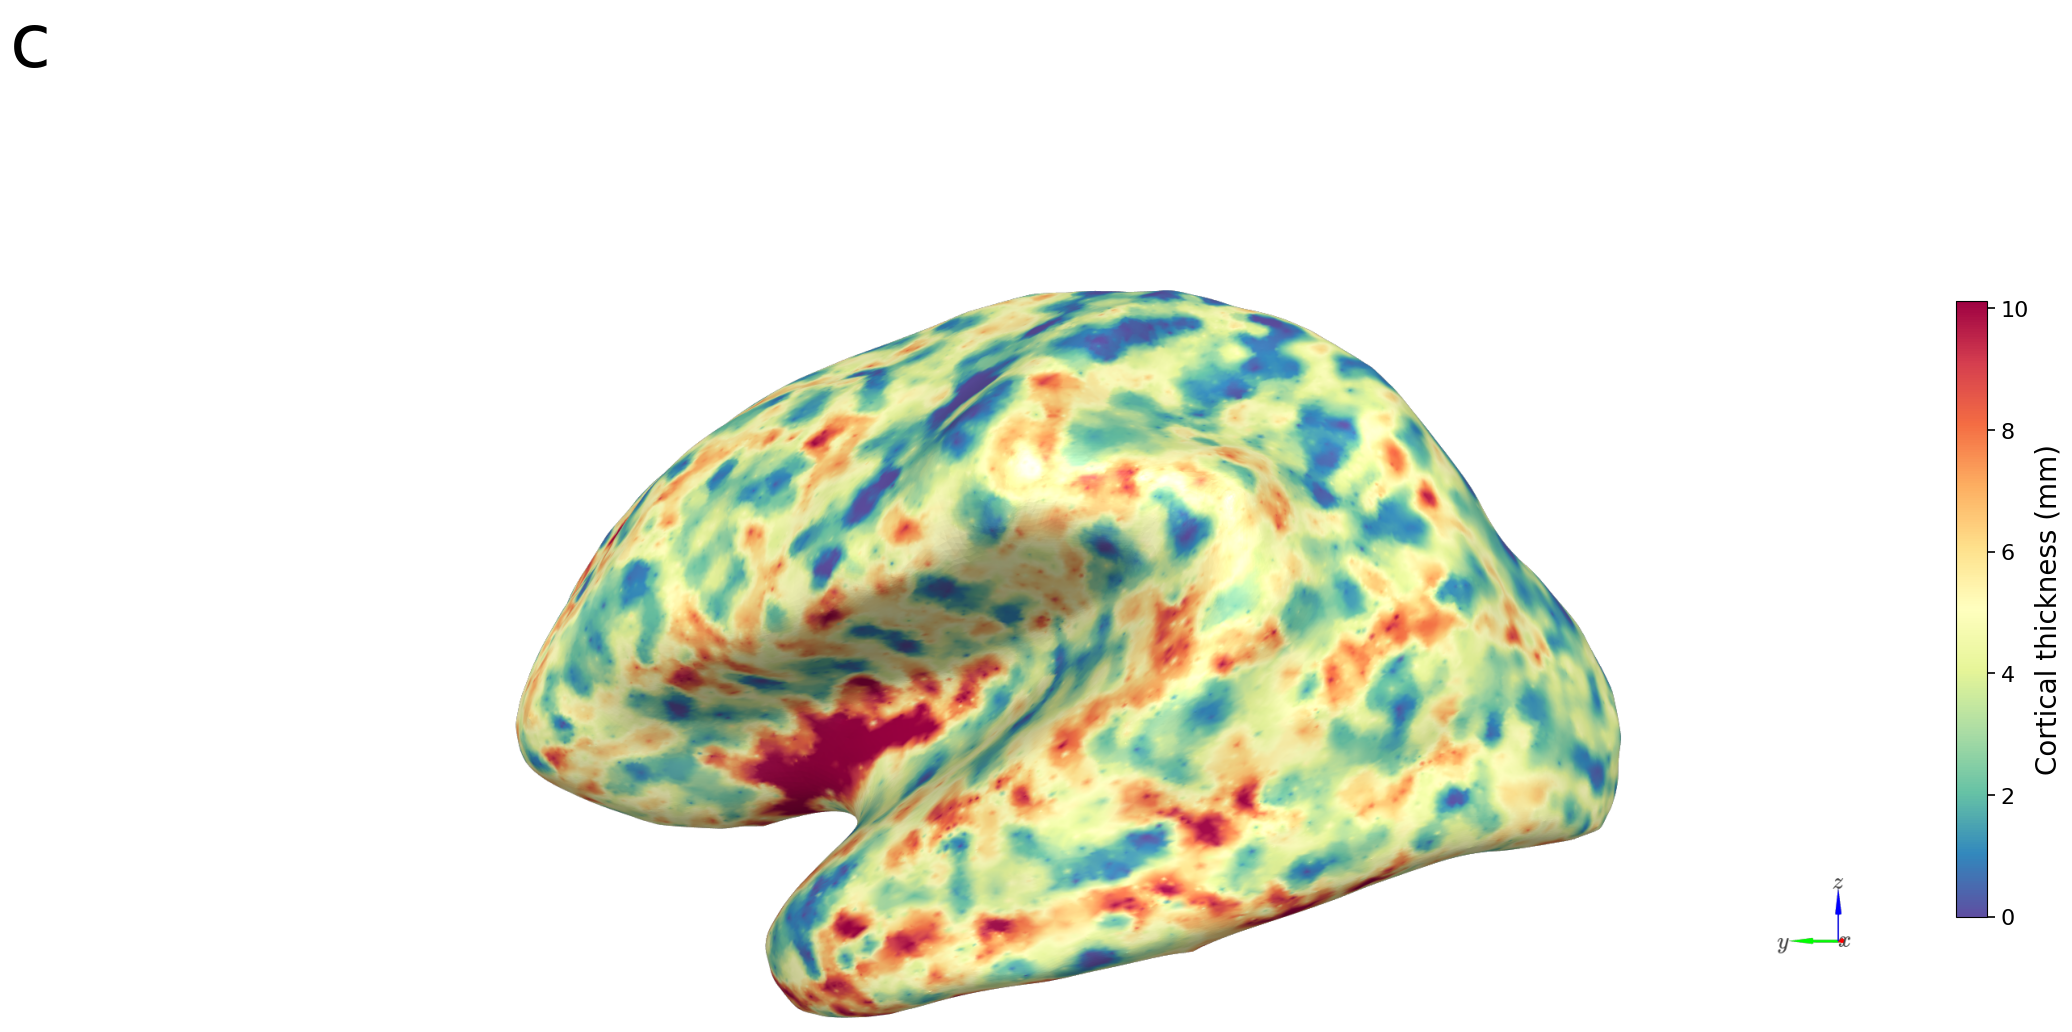

In [21]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Cortical thickness (mm)", fontsize=20)

add_subplot_label(ax, 'c', fontsize=54)

# Show and save figure
plt.savefig(f"figure_07_thickness.pdf")


In [10]:
def compute_bias(matrix):
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("The input matrix must be square.")
    
    n = matrix.shape[0]
    bias = np.zeros((n,1))
    
    # Loop through each column and check if the maximum value is on the diagonal
    for j in range(n):
        max_index = np.argmax(matrix[:, j])
        bias[j] = max_index-j 
    
    return np.mean(bias)


def compute_error(matrix):
    if matrix.shape[0] != matrix.shape[1]:
        raise ValueError("The input matrix must be square.")
    
    n = matrix.shape[0]
    error = np.zeros((n,1))
    
    # Loop through each column and check if the maximum value is on the diagonal
    for j in range(n):
        max_index = np.argmax(matrix[:, j])
        error[j] = np.abs(j-max_index)
    
    return np.mean(error)

In [42]:
v_idx=[]
bias_surf=[]
bias_mm=[]
error_surf=[]
error_mm=[]
error_layer_surf=[]
error_layer_mm=[]

fnames=sorted(glob.glob(os.path.join(out_dir, f'vx_*_snr_{snr}_winsize_{win_size}.pickle')))
for f_idx, fname in enumerate(fnames):
    with open(fname,'rb') as file:
        results=pickle.load(file)
    vertex=results['sim_vertex']
    norm_layerF = np.zeros((n_layers, n_layers))
    v_err=[]
    v_err_mm=[]
    for l in range(n_layers):
        norm_layerF[:,l] = results['layerF'][:,l]-np.min(results['layerF'][:,l])                
        v_err.append(np.abs(np.argmax(norm_layerF[:,l])-l))
        v_err_mm.append(np.abs(np.argmax(norm_layerF[:,l])-l)*thickness[vertex])
    error_layer_surf.append(v_err)
    error_layer_mm.append(v_err_mm)

    b = compute_bias(norm_layerF)
    e = compute_error(norm_layerF)
    v_idx.append(vertex)
    bias_surf.append(b)
    bias_mm.append(b*thickness[vertex])
    error_surf.append(e)
    error_mm.append(e*thickness[vertex])
v_idx=np.array(v_idx)
bias_surf=np.array(bias_surf)
bias_mm=np.array(bias_mm)
error_surf=np.array(error_surf)
error_mm=np.array(error_mm)
error_layer_surf=np.array(error_layer_surf)
error_layer_mm=np.array(error_layer_mm)

In [12]:
len(v_idx)

20945

In [41]:
error_mm[np.where(v_idx==5195)[0]]

array([0.])

In [13]:
layer_lf_mat=np.zeros((verts_per_surf, n_layers, lf_mat.shape[1]))
diff_layer_lf_mat=np.zeros((verts_per_surf, n_layers))
for i in range(n_layers):
    layer_lf_mat[:,i,:]=lf_mat[i*verts_per_surf:(i+1)*verts_per_surf,:]
for j in range(verts_per_surf):
    for i in range(n_layers):
        diff_layer_lf_mat[j,i]=np.sqrt(np.mean((layer_lf_mat[j,i,:]-layer_lf_mat[j,0,:])**2))

In [120]:
# Plot colors and camera view
interpolated_data = interpolate_data(orig_inflated, ds_inflated, diff_layer_lf_mat[:,-1])
c_range = [np.percentile(interpolated_data,1), np.percentile(interpolated_data,99)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [29]:
plot.fetch_screenshot()

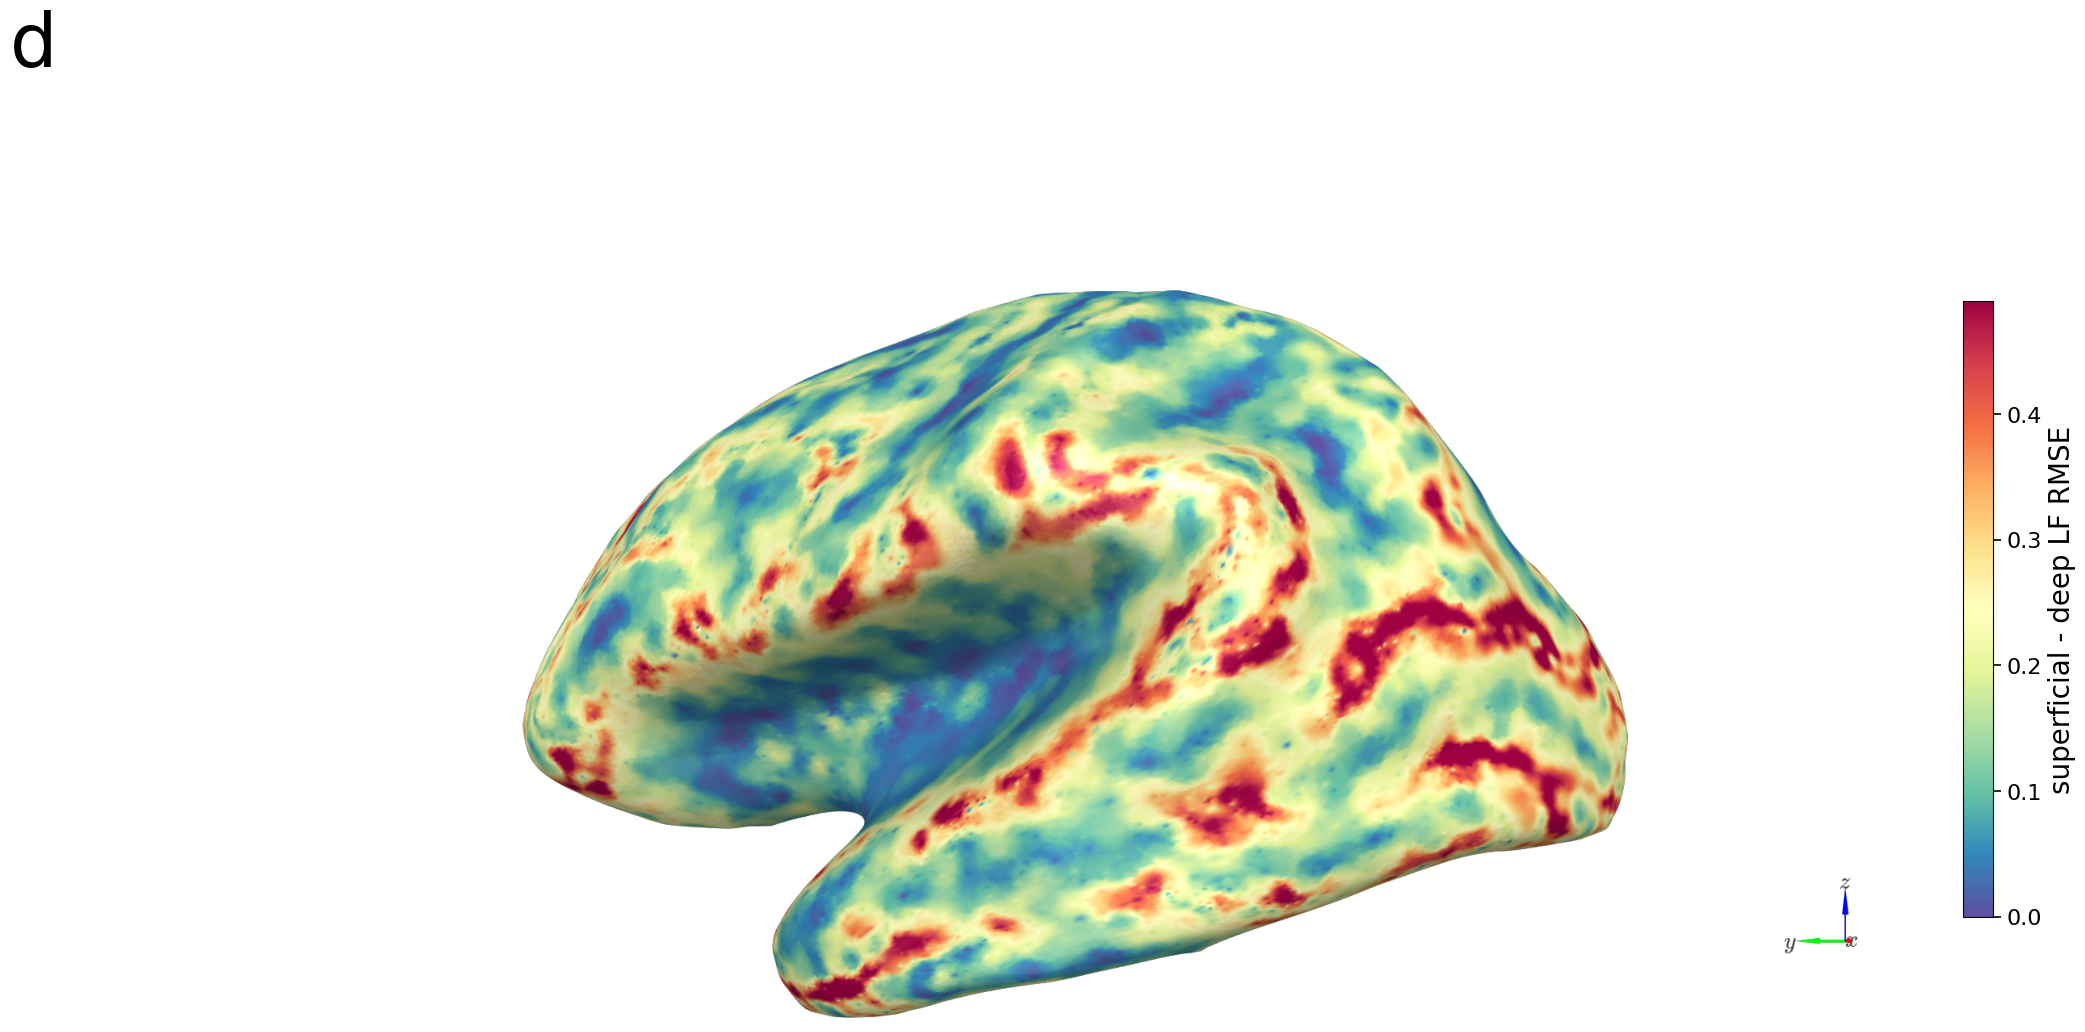

In [32]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("superficial - deep LF RMSE", fontsize=20)

add_subplot_label(ax, 'd', fontsize=54)

# Show and save figure
plt.savefig(f"figure_07_lead_field.pdf")

In [293]:
# Plot colors and camera view
error_all=np.zeros(verts_per_surf)
error_all[v_idx]=error_mm
interpolated_data = interpolate_data(orig_inflated, ds_inflated, error_all)
c_range = [0, np.percentile(interpolated_data,99.9)]
cam_view=[289, 32, -19,
          3.5, 29, 26,
          0, 0, 1]

# Plot change in power on each surface
colors,_ = color_map(
    interpolated_data, 
    "Spectral_r", 
    c_range[0], 
    c_range[1],
    norm='N'
)
plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


In [34]:
plot.fetch_screenshot()

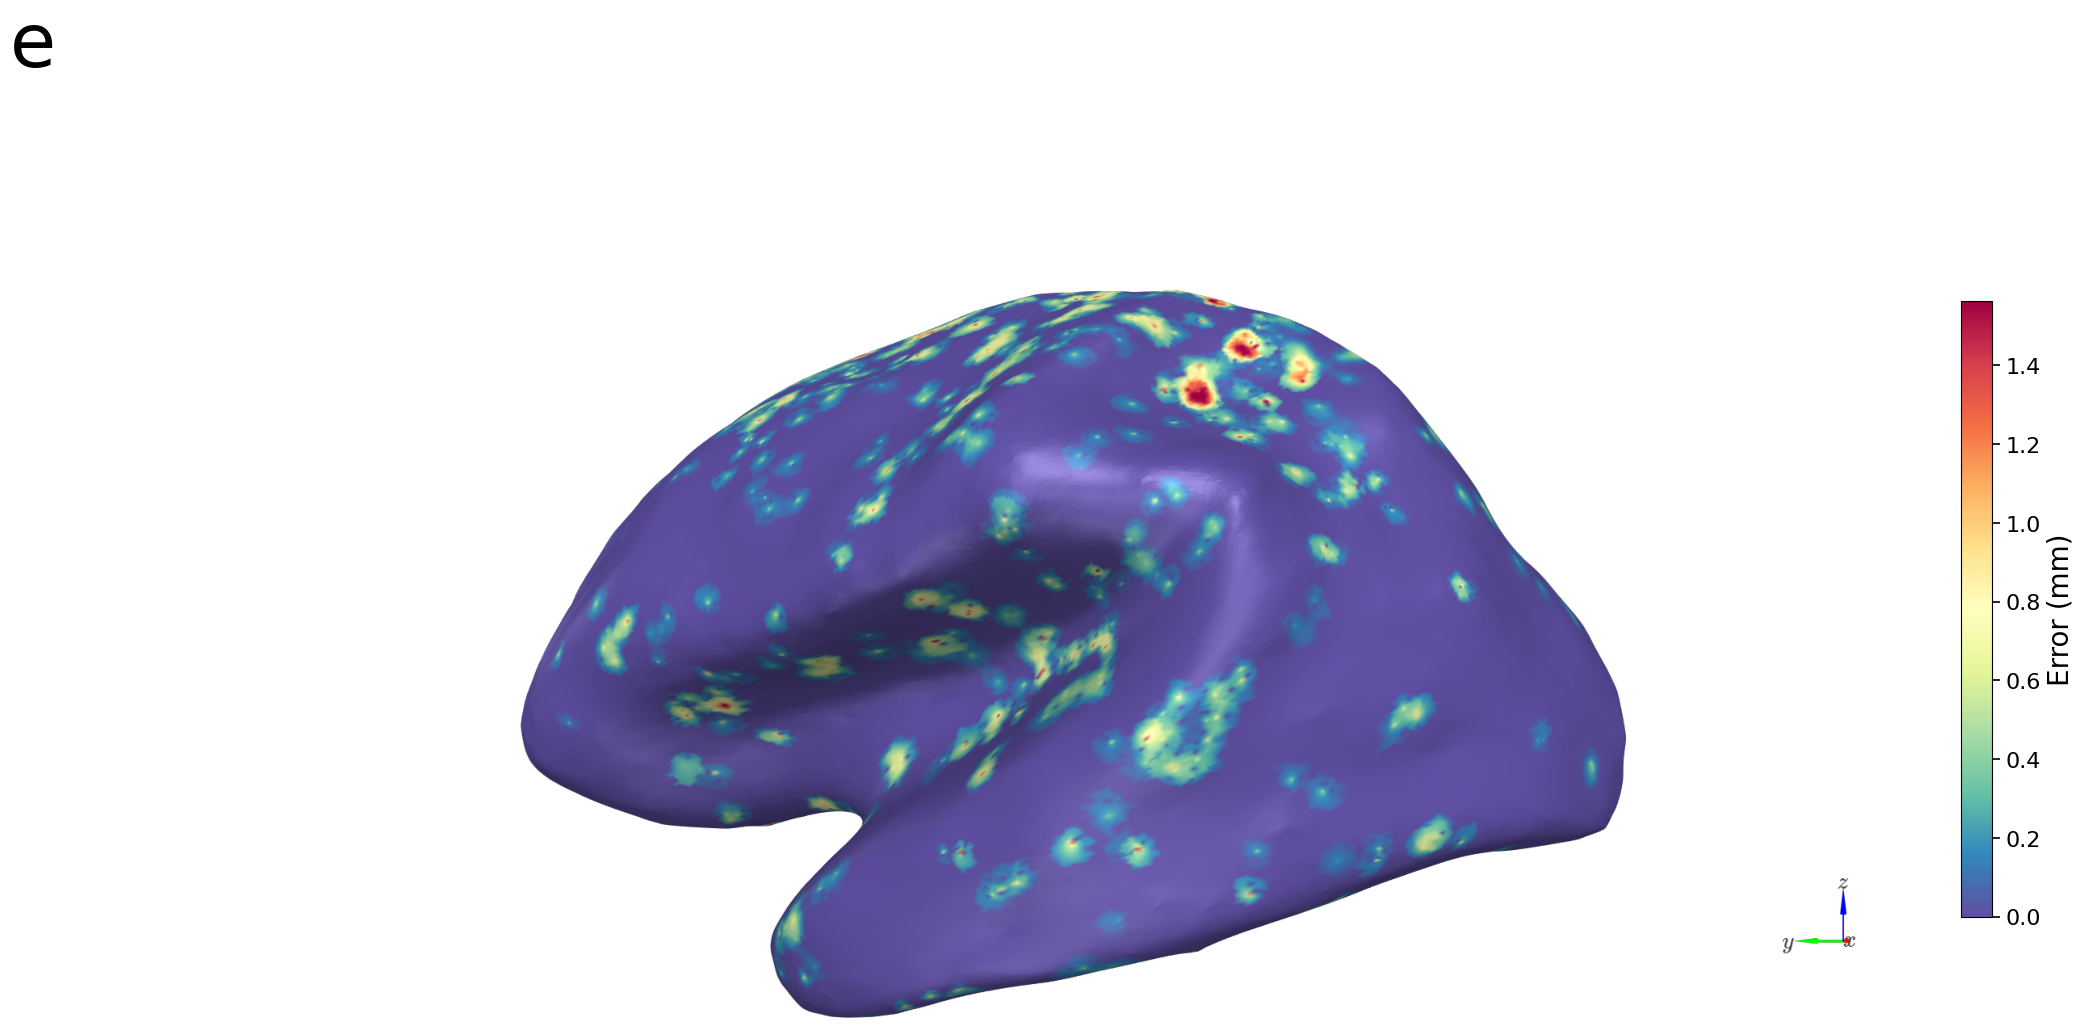

In [36]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

# Create a ScalarMappable for the colorbar
vmin, vmax = np.min(interpolated_data), np.max(interpolated_data)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
scalar_mappable = cm.ScalarMappable(norm=norm, cmap="Spectral_r")

# Add colorbar
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=0.5, aspect=20, pad=0.02)
cbar.set_label("Error (mm)", fontsize=20)

add_subplot_label(ax, 'e', fontsize=54)

# Show and save figure
plt.savefig(f"figure_07_error_mm.pdf")

In [43]:
for l in range(n_layers):
    # Plot colors and camera view
    error_layer_all=np.zeros(verts_per_surf)
    error_layer_all[v_idx]=error_layer_mm[:,l]
    interpolated_data = interpolate_data(orig_inflated, ds_inflated, error_layer_all)
    c_range = [0, np.percentile(interpolated_data,99.9)]
    cam_view=[289, 32, -19,
              3.5, 29, 26,
              0, 0, 1]

    # Plot change in power on each surface
    colors,_ = color_map(
        interpolated_data, 
        "Spectral_r", 
        c_range[0], 
        c_range[1],
        norm='N'
    )
    plot = show_surface(orig_inflated, vertex_colors=colors, info=True, camera_view=left_side_view)

Output()

317496 vertices


Output()

317496 vertices


Output()

...

317496 vertices


Output()

317496 vertices


Output()

317496 vertices


In [299]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

def plot_joint_kde(x_vals, y_vals, error_mm, x_label, y_label, ax_label, x_per=[0,100],y_per=[0,100]):
    """
    This version ensures the right marginal KDE axis remains at the original size
    (e.g., [0.915, 0.11, 0.175, 0.775]), and the color bar is placed beyond x=1.0.
    You might need to adjust figure size or use plt.subplots_adjust() to avoid clipping.
    """

    # 1) Filter out outliers if needed
    x_l = np.percentile(x_vals, x_per)
    y_l = np.percentile(y_vals, y_per)
    idx = ((x_vals >= x_l[0]) & (x_vals <= x_l[1]) &
           (y_vals >= y_l[0]) & (y_vals <= y_l[1]))
    x_filt = x_vals[idx]
    y_filt = y_vals[idx]
    err_filt = error_mm[idx]

    # 2) Sort by error so higher-error points are on top
    sort_idx = np.argsort(err_filt)
    x_sorted = x_filt[sort_idx]
    y_sorted = y_filt[sort_idx]
    err_sorted = err_filt[sort_idx]

    # 3) Main scatter plot
    #    By default, this axis is around [0.125, 0.11, 0.775, 0.775].
    fig, ax_scatter = plt.subplots()
    sc = ax_scatter.scatter(
        x_sorted,
        y_sorted,
        c=err_sorted,
        cmap='Spectral_r',
        marker='.',
        edgecolors='none',
        alpha=0.5,
        rasterized=True
    )
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # 4) Top marginal axis (KDE in X dimension).
    #    For example, [0.125, 0.9, 0.775, 0.2].
    ax_histx = fig.add_axes([0.125, 0.9, 0.775, 0.2])

    # 5) Right marginal axis (KDE in Y dimension), full original width:
    #    e.g. [0.915, 0.11, 0.175, 0.775].
    #    We do NOT shrink it.
    ax_histy = fig.add_axes([0.915, 0.11, 0.175, 0.775])

    # 6) Add the color bar axis EVEN FARTHER to the right, e.g. x=1.095
    #    That means the figure's total width in normalized coords is ~1.115.
    ax_cbar = fig.add_axes([1.095, 0.11, 0.02, 0.775])
    cbar = fig.colorbar(sc, cax=ax_cbar)
    cbar.set_label("Error (mm)")

    # 7) Define one bin for error=0, plus N equally spaced bins for errors>0
    bin_0_mask = (err_sorted == 0)
    nonzero_err = err_sorted[err_sorted > 0]

    if len(nonzero_err) <= 1:
        # If everything is zero or there's only one unique nonzero error
        nonzero_bins = np.array([0, 1])
    else:
        num_nonzero_bins = 3  # e.g., 3 bins
        min_err = nonzero_err.min()
        max_err = nonzero_err.max()
        nonzero_bins = np.linspace(min_err, max_err, num_nonzero_bins + 1)

    # Build bin masks
    bin_masks  = []
    bin_colors = []
    
    cmap = plt.get_cmap("Spectral_r")

    color_0 = cmap(0.0)
    bin_masks.append(bin_0_mask)
    bin_colors.append(color_0)
    
    color_increments = np.linspace(0.2, 0.9, num_nonzero_bins)
    for i in range(num_nonzero_bins):
        low  = nonzero_bins[i]
        high = nonzero_bins[i+1]
        if i < num_nonzero_bins - 1:
            mask = (err_sorted >= low) & (err_sorted < high)
        else:
            mask = (err_sorted >= low) & (err_sorted <= high)
        
        bin_masks.append(mask)
        bin_color = cmap(color_increments[i])
        bin_colors.append(bin_color)

    # 8) KDE plotting
    from scipy.stats import gaussian_kde
    def plot_kde_x(data, color):
        if len(data) < 2:
            return
        kde = gaussian_kde(data)
        x_grid = np.linspace(x_filt.min(), x_filt.max(), 200)
        pdf = kde(x_grid)
        ax_histx.plot(x_grid, pdf, color=color, alpha=0.8, lw=1.5)
        ax_histx.fill_between(x_grid, pdf, color=color, alpha=0.2)

    def plot_kde_y(data, color):
        if len(data) < 2:
            return
        kde = gaussian_kde(data)
        y_grid = np.linspace(y_filt.min(), y_filt.max(), 200)
        pdf = kde(y_grid)
        ax_histy.plot(pdf, y_grid, color=color, alpha=0.8, lw=1.5)
        ax_histy.fill_betweenx(y_grid, 0, pdf, color=color, alpha=0.2)

    # 9) Plot the KDE for each bin
    for mask, color in zip(bin_masks, bin_colors):
        plot_kde_x(x_sorted[mask], color)
        plot_kde_y(y_sorted[mask], color)

    # 10) Style marginal axes
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])
    ax_histx.set_ylabel("KDE")

    ax_histy.set_xticks([])
    ax_histy.set_yticks([])
    ax_histy.set_xlabel("KDE")

    # 11) Hide top and right spines
    for ax in [ax_scatter, ax_histx, ax_histy]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # 12) Possibly adjust figure size or use plt.subplots_adjust() if needed
    #     For example, to ensure nothing is clipped:
    # plt.subplots_adjust(right=1.08)  # or more

    # 13) Add subplot label if desired
    add_subplot_label(ax_scatter, ax_label, x=-0.15, y=1.3)


In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc, roc_auc_score

def add_subplot_label(ax, label, x=-0.1, y=1.05):
    """Add a label to a subplot."""
    ax.text(x, y, label, transform=ax.transAxes, 
            fontsize=12, fontweight='bold', va='top')

def plot_joint_kde(x_vals, y_vals, error_mm, x_label, y_label, ax_label, x_per=[0,100], y_per=[0,100]):
    """
    Plot joint KDE with separation lines for optimal thresholds that separate
    zero-error points from non-zero-error points, ensuring thresholds are within
    the data range.
    """

    # 1) Filter out outliers if needed
    x_l = np.percentile(x_vals, x_per)
    y_l = np.percentile(y_vals, y_per)
    idx = ((x_vals >= x_l[0]) & (x_vals <= x_l[1]) &
           (y_vals >= y_l[0]) & (y_vals <= y_l[1]))
    x_filt = x_vals[idx]
    y_filt = y_vals[idx]
    err_filt = error_mm[idx]

    # 2) Sort by error so higher-error points are on top
    sort_idx = np.argsort(err_filt)
    x_sorted = x_filt[sort_idx]
    y_sorted = y_filt[sort_idx]
    err_sorted = err_filt[sort_idx]

    # 3) Create the figure with the correct layout - IMPORTANT: Use gridspec for alignment
    fig = plt.figure(figsize=(10, 8))
    
    # Define the grid layout with proper spacing
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                         left=0.1, right=0.9, bottom=0.1, top=0.9,
                         wspace=0.05, hspace=0.05)
    
    # Create the axes with exact alignment
    ax_scatter = fig.add_subplot(gs[1, 0])  # Main scatter plot
    ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)  # Top marginal
    ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)  # Right marginal
    
    # Add color bar axis
    ax_cbar = fig.add_axes([0.95, 0.1, 0.02, 0.8])
    
    # Main scatter plot
    sc = ax_scatter.scatter(
        x_sorted,
        y_sorted,
        c=err_sorted,
        cmap='Spectral_r',
        marker='.',
        edgecolors='none',
        alpha=0.5,
        rasterized=True
    )
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    # Add color bar
    cbar = fig.colorbar(sc, cax=ax_cbar)
    cbar.set_label("Error (mm)")

    # 7) Define one bin for error=0, plus N equally spaced bins for errors>0
    bin_0_mask = (err_sorted == 0)
    nonzero_err = err_sorted[err_sorted > 0]

    if len(nonzero_err) <= 1:
        nonzero_bins = np.array([0, 1])
    else:
        num_nonzero_bins = 3
        min_err = nonzero_err.min()
        max_err = nonzero_err.max()
        nonzero_bins = np.linspace(min_err, max_err, num_nonzero_bins + 1)

    # Build bin masks
    bin_masks = []
    bin_colors = []
    
    cmap = plt.get_cmap("Spectral_r")

    color_0 = cmap(0.0)
    bin_masks.append(bin_0_mask)
    bin_colors.append(color_0)
    
    color_increments = np.linspace(0.2, 0.9, num_nonzero_bins)
    for i in range(num_nonzero_bins):
        low = nonzero_bins[i]
        high = nonzero_bins[i+1]
        if i < num_nonzero_bins - 1:
            mask = (err_sorted >= low) & (err_sorted < high)
        else:
            mask = (err_sorted >= low) & (err_sorted <= high)
        
        bin_masks.append(mask)
        bin_color = cmap(color_increments[i])
        bin_colors.append(bin_color)

    # 8) KDE plotting for zero and non-zero error groups
    x_zero_mask = (err_filt == 0)
    x_nonzero_mask = (err_filt > 0)
    y_zero_mask = (err_filt == 0)
    y_nonzero_mask = (err_filt > 0)
    
    # Zero error KDEs
    zero_color = cmap(0.0)
    nonzero_color = cmap(0.7)
    
    # Function to calculate KDEs
    def plot_kde_x(data, color):
        if len(data) < 2:
            return None, None
        kde = gaussian_kde(data)
        x_grid = np.linspace(x_filt.min(), x_filt.max(), 200)
        pdf = kde(x_grid)
        ax_histx.plot(x_grid, pdf, color=color, alpha=0.8, lw=1.5)
        ax_histx.fill_between(x_grid, pdf, color=color, alpha=0.2)
        return x_grid, pdf

    def plot_kde_y(data, color):
        if len(data) < 2:
            return None, None
        kde = gaussian_kde(data)
        y_grid = np.linspace(y_filt.min(), y_filt.max(), 200)
        pdf = kde(y_grid)
        ax_histy.plot(pdf, y_grid, color=color, alpha=0.8, lw=1.5)
        ax_histy.fill_betweenx(y_grid, 0, pdf, color=color, alpha=0.2)
        return y_grid, pdf
        
    # Plot KDEs for each bin
    for mask, color in zip(bin_masks, bin_colors):
        plot_kde_x_result = plot_kde_x(x_sorted[mask], color)
        plot_kde_y_result = plot_kde_y(y_sorted[mask], color)
    
    def plot_kde(data, axis_type):
        """Helper function to compute KDE without plotting."""
        if len(data) < 2:
            return None, None
        kde = gaussian_kde(data)
        if axis_type == "x":
            grid = np.linspace(x_filt.min(), x_filt.max(), 200)
        else:
            grid = np.linspace(y_filt.min(), y_filt.max(), 200)
        pdf = kde(grid)
        return grid, pdf
    
    # 10) Calculate KDEs for zero and non-zero error groups separately
    # This will be used for finding intersections or better thresholds
    zero_x_grid, zero_x_pdf = None, None
    nonzero_x_grid, nonzero_x_pdf = None, None
    zero_y_grid, zero_y_pdf = None, None
    nonzero_y_grid, nonzero_y_pdf = None, None
    
    if np.sum(x_zero_mask) >= 2:
        zero_x_grid, zero_x_pdf = plot_kde(x_filt[x_zero_mask], "x")
    
    if np.sum(x_nonzero_mask) >= 2:
        nonzero_x_grid, nonzero_x_pdf = plot_kde(x_filt[x_nonzero_mask], "x")
    
    if np.sum(y_zero_mask) >= 2:
        zero_y_grid, zero_y_pdf = plot_kde(y_filt[y_zero_mask], "y")
    
    if np.sum(y_nonzero_mask) >= 2:
        nonzero_y_grid, nonzero_y_pdf = plot_kde(y_filt[y_nonzero_mask], "y")
    
    # 11) Find optimal threshold
    binary_error = (err_filt > 0).astype(int)
    
    # Prepare results dictionary
    results = {
        'x_threshold': None,
        'y_threshold': None,
        'x_auc': None,
        'y_auc': None,
        'x_threshold_method': None,
        'y_threshold_method': None
    }
    
    # Function to find optimal threshold within range
    def find_best_threshold(values, errors, axis_type):
        """Find the best threshold to separate zero/non-zero error points."""
        # 1. First try KDE intersection if both distributions are valid
        if axis_type == 'x' and zero_x_grid is not None and nonzero_x_grid is not None:
            # Interpolate both PDFs to a common grid
            common_grid = np.linspace(x_filt.min(), x_filt.max(), 500)
            zero_pdf_interp = np.interp(common_grid, zero_x_grid, zero_x_pdf)
            nonzero_pdf_interp = np.interp(common_grid, nonzero_x_grid, nonzero_x_pdf)
            
            # Find intersections
            intersect_diffs = zero_pdf_interp - nonzero_pdf_interp
            sign_changes = np.where(np.diff(np.signbit(intersect_diffs)))[0]
            
            if len(sign_changes) > 0:
                # Find the intersection with the highest sum of PDFs (most significant)
                best_idx = np.argmax(zero_pdf_interp[sign_changes] + nonzero_pdf_interp[sign_changes])
                intersection_idx = sign_changes[best_idx]
                intersection_value = common_grid[intersection_idx]
                
                # Only use if within the middle 90% of the data range
                min_val, max_val = np.min(values), np.max(values)
                range_margin = 0.05 * (max_val - min_val)
                
                if (intersection_value > min_val + range_margin and 
                    intersection_value < max_val - range_margin):
                    return intersection_value, "kde_intersection"
        
        elif axis_type == 'y' and zero_y_grid is not None and nonzero_y_grid is not None:
            # Interpolate both PDFs to a common grid
            common_grid = np.linspace(y_filt.min(), y_filt.max(), 500)
            zero_pdf_interp = np.interp(common_grid, zero_y_grid, zero_y_pdf)
            nonzero_pdf_interp = np.interp(common_grid, nonzero_y_grid, nonzero_y_pdf)
            
            # Find intersections
            intersect_diffs = zero_pdf_interp - nonzero_pdf_interp
            sign_changes = np.where(np.diff(np.signbit(intersect_diffs)))[0]
            
            if len(sign_changes) > 0:
                # Find the intersection with the highest sum of PDFs (most significant)
                best_idx = np.argmax(zero_pdf_interp[sign_changes] + nonzero_pdf_interp[sign_changes])
                intersection_idx = sign_changes[best_idx]
                intersection_value = common_grid[intersection_idx]
                
                # Only use if within the middle 90% of the data range
                min_val, max_val = np.min(values), np.max(values)
                range_margin = 0.05 * (max_val - min_val)
                
                if (intersection_value > min_val + range_margin and 
                    intersection_value < max_val - range_margin):
                    return intersection_value, "kde_intersection"
        
        # 2. Try ROC curve analysis
        if len(np.unique(errors)) > 1 and len(np.unique(values)) > 1:
            # Calculate ROC curve
            fpr, tpr, thresholds = roc_curve(errors, values)
            
            # Calculate AUC
            roc_auc = auc(fpr, tpr)
            
            # Find the threshold that maximizes the Youden's J statistic (tpr - fpr)
            j_scores = tpr - fpr
            optimal_idx = np.argmax(j_scores)
            optimal_threshold = thresholds[optimal_idx]
            
            # Check if threshold is at or near data range boundaries
            min_val, max_val = np.min(values), np.max(values)
            value_range = max_val - min_val
            boundary_margin = 0.05 * value_range  # 5% of data range
            
            # If near boundary, look for the next best threshold within range
            if abs(optimal_threshold - min_val) < boundary_margin or abs(optimal_threshold - max_val) < boundary_margin:
                # Sort J scores while excluding boundary thresholds
                valid_indices = []
                for i, t in enumerate(thresholds):
                    if t > min_val + boundary_margin and t < max_val - boundary_margin:
                        valid_indices.append(i)
                
                if valid_indices:
                    # Find best non-boundary threshold
                    valid_j_scores = [j_scores[i] for i in valid_indices]
                    best_valid_idx = valid_indices[np.argmax(valid_j_scores)]
                    optimal_threshold = thresholds[best_valid_idx]
                    return optimal_threshold, "roc_within_range"
                else:
                    # No good threshold found within range, use median
                    return np.median(values), "median_fallback"
            else:
                # Original threshold is already within reasonable range
                return optimal_threshold, "roc_optimal"
        
        # 3. Fallback: use median value
        return np.median(values), "median_fallback"
    
    # Hide x ticks for the top plot
    ax_histx.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax_histx.set_ylabel("KDE")
    
    # Hide y ticks for the right plot
    ax_histy.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax_histy.set_xlabel("KDE")

    # For X variable
    if len(np.unique(binary_error)) > 1:
        # Calculate original ROC curve for AUC
        fpr_x, tpr_x, _ = roc_curve(binary_error, x_filt)
        auc_x = auc(fpr_x, tpr_x)
        results['x_auc'] = auc_x
        
        # Find best threshold within range
        x_threshold, x_method = find_best_threshold(x_filt, binary_error, 'x')
        results['x_threshold'] = x_threshold
        results['x_threshold_method'] = x_method
        
        # Add vertical line to both plots at EXACTLY the same x position
        ymax_x = ax_histx.get_ylim()[1]
        ax_histx.axvline(x=x_threshold, color='k', linestyle='--', linewidth=1.5)
#         ax_scatter.axvline(x=x_threshold, color='k', linestyle='--', linewidth=1)
        
        # Add label with method information
#         method_display = {
#             'kde_intersection': 'KDE intersection',
#             'roc_optimal': 'ROC optimal',
#             'roc_within_range': 'ROC (range-constrained)',
#             'median_fallback': 'median fallback'
#         }
        
#         label_text = f'x={x_threshold:.3f}\n({method_display[x_method]}, AUC={auc_x:.2f})'
#         ax_histx.text(x_threshold, ymax_x*0.9, label_text, 
#                      ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7))
        
        # Print results with context
        print(f"X variable (AUC={auc_x:.3f}):")
        print(f"  Optimal threshold: {x_threshold:.3f}")
        
        # Calculate accuracy of this threshold
        x_predictions = (x_filt > x_threshold).astype(int)
        x_accuracy = np.mean(x_predictions == binary_error)
        print(f"  Threshold accuracy: {x_accuracy:.3f}")
    else:
        print("Cannot compute optimal X threshold: insufficient unique error values")
    
    # For Y variable
    if len(np.unique(binary_error)) > 1:
        # Calculate original ROC curve for AUC
        fpr_y, tpr_y, _ = roc_curve(binary_error, y_filt)
        auc_y = auc(fpr_y, tpr_y)
        results['y_auc'] = auc_y
        
        # Find best threshold within range
        y_threshold, y_method = find_best_threshold(y_filt, binary_error, 'y')
        results['y_threshold'] = y_threshold
        results['y_threshold_method'] = y_method
        
        # Add horizontal line to both plots at EXACTLY the same y position
        xmax_y = ax_histy.get_xlim()[1]
        ax_histy.axhline(y=y_threshold, color='k', linestyle='--', linewidth=1.5)
#         ax_scatter.axhline(y=y_threshold, color='k', linestyle='--', linewidth=1)
        
        # Add label with method information
#         method_display = {
#             'kde_intersection': 'KDE intersection',
#             'roc_optimal': 'ROC optimal',
#             'roc_within_range': 'ROC (range-constrained)',
#             'median_fallback': 'median fallback'
#         }
        
#         label_text = f'y={y_threshold:.3f}\n({method_display[y_method]},\nAUC={auc_y:.2f})'
#         ax_histy.text(xmax_y*0.7, y_threshold, label_text, 
#                      ha='right', va='center', bbox=dict(facecolor='white', alpha=0.7))
        
        # Print results with context
        print(f"Y variable (AUC={auc_y:.3f}):")
        print(f"  Optimal threshold: {y_threshold:.3f}")
        
        # Calculate accuracy of this threshold
        y_predictions = (y_filt > y_threshold).astype(int)
        y_accuracy = np.mean(y_predictions == binary_error)
        print(f"  Threshold accuracy: {y_accuracy:.3f}")
    else:
        print("Cannot compute optimal Y threshold: insufficient unique error values")

    # Hide top and right spines
    for ax in [ax_scatter, ax_histx, ax_histy]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Add subplot label if desired
    add_subplot_label(ax_scatter, ax_label, x=-0.15, y=1.3)
    
    # Return the results dictionary for reference
    return fig, results

X variable (AUC=0.697):
  Optimal threshold: 25.569
  Threshold accuracy: 0.532
Y variable (AUC=0.242):
  Optimal threshold: 0.093
  Threshold accuracy: 0.367


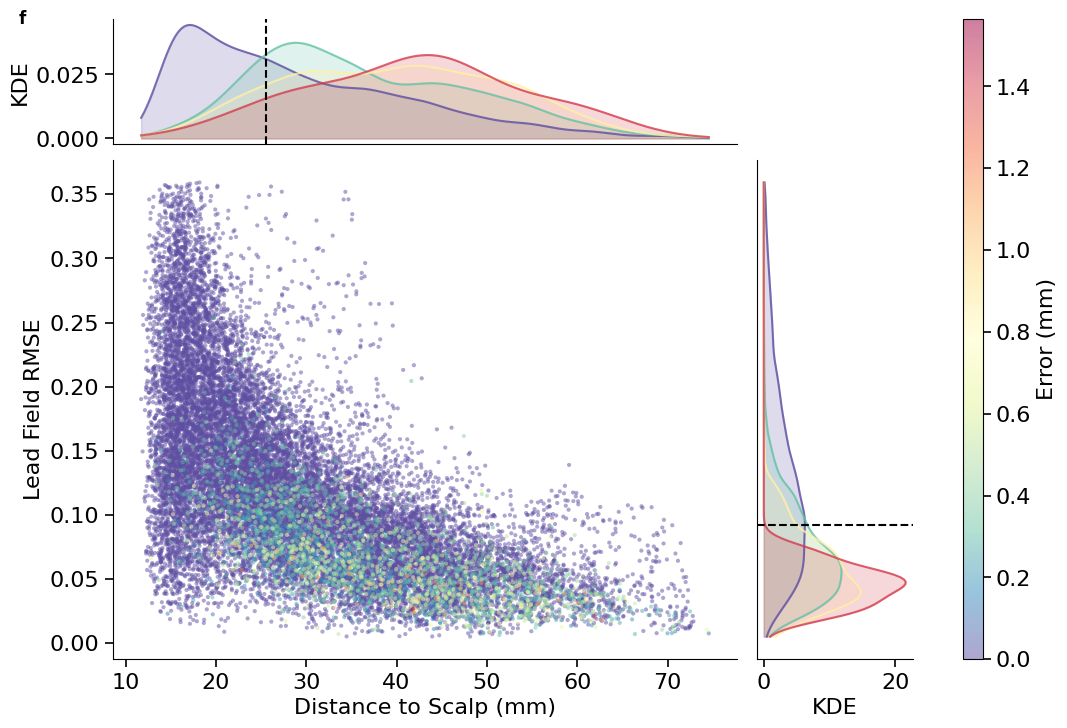

In [39]:
ax=plot_joint_kde(distances[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Distance to Scalp (mm)', 'Lead Field RMSE','f',y_per=[.1,99.1])
plt.savefig(f"figure_07_dist_lf.pdf", bbox_inches='tight')

X variable (AUC=0.394):
  Optimal threshold: 0.685
  Threshold accuracy: 0.551
Y variable (AUC=0.242):
  Optimal threshold: 0.093
  Threshold accuracy: 0.367


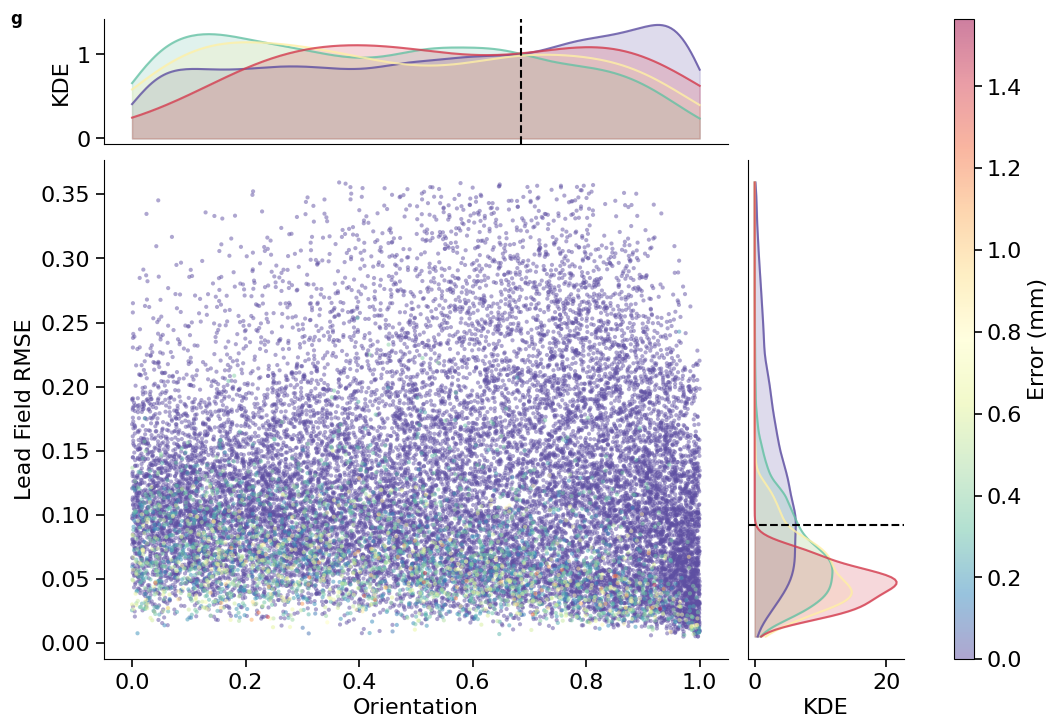

In [40]:
plot_joint_kde(dot_products[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Orientation', 'Lead Field RMSE','g',y_per=[.1,99.1])
plt.savefig(f"figure_07_ori_lf.pdf", bbox_inches='tight')

X variable (AUC=0.259):
  Optimal threshold: 2.949
  Threshold accuracy: 0.291
Y variable (AUC=0.242):
  Optimal threshold: 0.092
  Threshold accuracy: 0.363


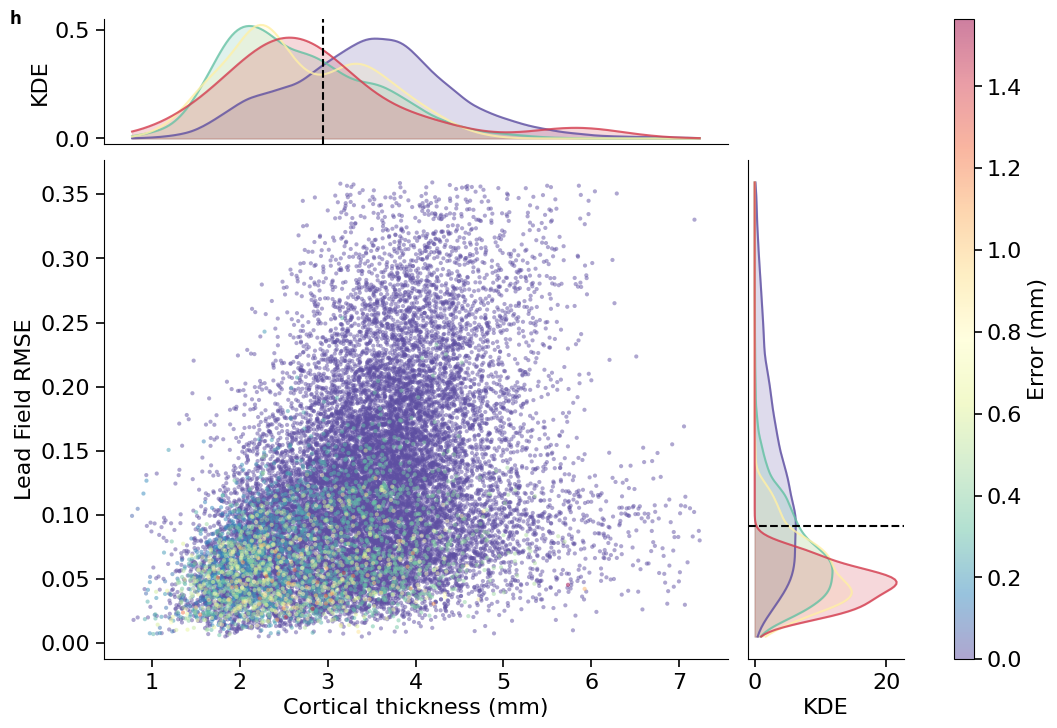

In [41]:
plot_joint_kde(thickness[v_idx], diff_layer_lf_mat[v_idx,-1], error_mm, 'Cortical thickness (mm)', 'Lead Field RMSE','h', x_per=[.1,99.9],y_per=[.1,99.1])
plt.savefig(f"figure_07_thick_lf.pdf", bbox_inches='tight')

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample
from torch.nn.parallel import DataParallel
from torch.cuda.amp import autocast, GradScaler
import os
from joblib import Parallel, delayed, parallel_backend
import multiprocessing

# Get number of CPU cores for joblib
num_cores = multiprocessing.cpu_count()
print(f"Using {num_cores} CPU cores")

# Enable PyTorch to use multiple threads
torch.set_num_threads(num_cores)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### Data Preparation
# Assume v_idx is defined. For example, v_idx could be np.arange(verts_per_surf)
N = len(v_idx)  # number of selected vertices
n_layers = layer_lf_mat.shape[1]
sensors = layer_lf_mat.shape[2]

# More efficient NumPy operations by avoiding redundant calculations
def prepare_features(v_idx, distances, dot_products, thickness):
    # Pre-index once to avoid repeated indexing
    dist = distances[v_idx]
    dots = dot_products[v_idx]
    thick = thickness[v_idx]
    log_thick = np.log(thick + 1e-8)
    thick_squared = thick**2
    
    # Add interaction features
    dist_thick = dist * thick  # Interaction between distance and thickness
    dist_log_thick = dist * log_thick  # Interaction with log thickness
    dist_thick_ratio = dist / (thick + 1e-8)  # Ratio as another interaction form
    
    # Use np.column_stack once with all features
    return np.column_stack((
        dist, dots, thick, thick_squared, log_thick,
        dist_thick, dist_log_thick, dist_thick_ratio
    ))

# Use the optimized function
X_additional = prepare_features(v_idx, distances, dot_products, thickness)

# More efficient lead field extraction using memory views where possible
X_lead = layer_lf_mat[v_idx, :, :]  # shape (N, n_layers, sensors)

# Define binary target: 0 if error_mm == 0, 1 if error_mm > 0
y = (error_mm > 0).astype(np.int8)  # Using int8 instead of int to save memory

### Train/Test Split
X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    X_additional, X_lead, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the additional features using joblib parallelization
scaler = StandardScaler()
with parallel_backend("loky", n_jobs=num_cores):
    X1_train = scaler.fit_transform(X1_train)
    X1_test = scaler.transform(X1_test)

# More efficient normalization using joblib for parallelization
def normalize_sample(X_sample):
    norm = np.linalg.norm(X_sample.flatten())
    return X_sample / (norm + 1e-8)

def normalize_batch_parallel(X):
    # Process samples in parallel using joblib
    with parallel_backend("loky", n_jobs=num_cores):
        normalized = Parallel()(delayed(normalize_sample)(X[i]) for i in range(X.shape[0]))
    return np.array(normalized)

X2_train = normalize_batch_parallel(X2_train)
X2_test = normalize_batch_parallel(X2_test)

### Balance the Training Set by Under-sampling the Majority Class
# More efficient class separation
maj_indices = np.where(y_train == 0)[0]
min_indices = np.where(y_train == 1)[0]

X1_train_minority = X1_train[min_indices]
X2_train_minority = X2_train[min_indices]
n_minority = len(min_indices)

# Sample majority indices directly instead of the data
maj_indices_sampled = np.random.choice(maj_indices, size=n_minority * 2, replace=False)

# More efficient concatenation
X1_train_bal = np.vstack((X1_train[maj_indices_sampled], X1_train_minority))
X2_train_bal = np.vstack((X2_train[maj_indices_sampled], X2_train_minority))
y_train_bal = np.hstack((np.zeros(len(maj_indices_sampled), dtype=np.int8), 
                         np.ones(n_minority, dtype=np.int8)))

# Shuffle training set efficiently
shuffle_idx = np.random.permutation(len(y_train_bal))
X1_train_bal = X1_train_bal[shuffle_idx]
X2_train_bal = X2_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

### Convert Data to PyTorch Tensors with memory efficiency
# Specify dtype explicitly and pin memory for faster data loading
X1_train_tensor = torch.tensor(X1_train_bal, dtype=torch.float32, device=device)
X2_train_tensor = torch.tensor(X2_train_bal, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_bal, dtype=torch.float32, device=device).unsqueeze(1)

X1_test_tensor = torch.tensor(X1_test, dtype=torch.float32, device=device)
X2_test_tensor = torch.tensor(X2_test, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32, device=device).unsqueeze(1)

# Create a TensorDataset and DataLoader with joblib-compatible settings
class MultiInputDataset(TensorDataset):
    def __init__(self, x1, x2, y):
        # Pass arguments as *args to super().__init__
        super(MultiInputDataset, self).__init__(x1, x2, y)
        
    def __getitem__(self, index):
        return self.tensors[0][index], self.tensors[1][index], self.tensors[2][index]

train_dataset = MultiInputDataset(X1_train_tensor, X2_train_tensor, y_train_tensor)
# Optimize batch size based on available memory (larger batch = more parallelism)
optimal_batch_size = min(128, len(train_dataset))
# Use joblib-friendly settings (fewer workers since joblib handles parallelism)
train_loader = DataLoader(
    train_dataset, 
    batch_size=optimal_batch_size, 
    shuffle=True,
    num_workers=2,  # Use fewer workers since joblib will handle most parallelism
    pin_memory=device.type=='cuda',
    persistent_workers=True  # Keep worker processes alive between iterations
)

class ClassFocusedAttention(nn.Module):
    def __init__(self, feature_dim, class_weights=None):
        super(ClassFocusedAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        # Class weights for focusing on minority class
        # Store as a float value instead of a dictionary
        self.class_weight = 2.0
        if class_weights is not None:
            if isinstance(class_weights, dict):
                self.class_weight = class_weights.get('1', 2.0)
            else:
                self.class_weight = class_weights
        
    def forward(self, x, class_probs=None):
        # Basic attention weights
        attention_weights = self.attention(x)
        
        # If we have class probability information, use it to focus attention
        if class_probs is not None:
            # Reshape class_probs for broadcasting
            class_probs = class_probs.view(-1, 1)
            # Increase attention for features that help predict the minority class
            boost_factor = 1.0 + self.class_weight * class_probs
            attention_weights = attention_weights * boost_factor
            
        return x * attention_weights, attention_weights
    
### Neural Network Model Components
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # If dimensions change, we need a projection shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        residual = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += self.shortcut(residual)
        out = self.relu(out)
        
        return out

class DenseResidualBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super(DenseResidualBlock, self).__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        
        # If dimensions change, we need a projection shortcut
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )
    
    def forward(self, x):
        residual = x
        
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.fc2(out)
        out = self.bn2(out)
        
        out += self.shortcut(residual)
        out = self.relu(out)
        
        return out

### Optimized Multi-Input DNN Model with Memory Efficiency
class EnhancedResidualNet(nn.Module):
    def __init__(self, n_additional_features, n_layers, sensors, class_weight=2.0):
        super(EnhancedResidualNet, self).__init__()
        
        # CNN branch for lead field (2D: n_layers x sensors)
        self.conv_initial = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn_initial = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual blocks for CNN branch
        self.res_block1 = ResidualBlock(32, 32)
        self.res_block2 = ResidualBlock(32, 64, stride=2)  # Downsampling
        self.res_block3 = ResidualBlock(64, 64)
        self.res_block4 = ResidualBlock(64, 128, stride=2)  # Downsampling
        self.res_block5 = ResidualBlock(128, 128)
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # Fully connected branch for additional features with residual connections
        self.fc_add1 = DenseResidualBlock(n_additional_features, 32)
        self.fc_add2 = DenseResidualBlock(32, 64)
        self.fc_add3 = DenseResidualBlock(64, 64)
        
        # Enhanced attention mechanism with class focus
        self.attention_cnn = ClassFocusedAttention(128, class_weight)
        self.attention_fc = ClassFocusedAttention(64, class_weight)
        
        # Additional layer to estimate class probability for attention refinement
        self.class_estimator = nn.Sequential(
            nn.Linear(128 + 64, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # Combined fully connected layers
        self.fc_combined1 = nn.Linear(128 + 64, 128)
        self.bn_combined1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.5)
        
        self.fc_combined2 = DenseResidualBlock(128, 128)
        self.dropout2 = nn.Dropout(0.4)
        
        self.fc_combined3 = nn.Linear(128, 64)
        self.bn_combined3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.3)
        
        self.fc_out = nn.Linear(64, 1)  # Output a single logit
    
    def forward(self, x1, x2):
        # x1: additional features, shape (batch, n_additional_features)
        # x2: lead field, shape (batch, n_layers, sensors)
        
        # Process x2 with CNN and residual blocks
        x2 = x2.unsqueeze(1)  # Add channel dim: (batch, 1, n_layers, sensors)
        x2 = self.relu(self.bn_initial(self.conv_initial(x2)))
        
        x2 = self.res_block1(x2)
        x2 = self.res_block2(x2)
        x2 = self.res_block3(x2)
        x2 = self.res_block4(x2)
        x2 = self.res_block5(x2)
        
        x2 = self.global_avg_pool(x2)
        x2 = x2.view(x2.size(0), -1)  # flatten: (batch, 128)
        
        # Process x1 with FC residual blocks
        x1 = self.fc_add1(x1)
        x1 = self.fc_add2(x1)
        x1 = self.fc_add3(x1)  # (batch, 64)
        
        # First concatenate for preliminary class estimation
        x_concat = torch.cat((x1, x2), dim=1)
        class_prob_estimate = self.class_estimator(x_concat)
        
        # Apply enhanced attention mechanism with class focus
        x2_weighted, att_cnn = self.attention_cnn(x2, class_prob_estimate)
        x1_weighted, att_fc = self.attention_fc(x1, class_prob_estimate)
        
        # Concatenate weighted features
        x_combined = torch.cat((x1_weighted, x2_weighted), dim=1)
        
        # Process combined features
        x = self.relu(self.bn_combined1(self.fc_combined1(x_combined)))
        x = self.dropout1(x)
        
        x = self.fc_combined2(x)
        x = self.dropout2(x)
        
        x = self.relu(self.bn_combined3(self.fc_combined3(x)))
        x = self.dropout3(x)
        
        logits = self.fc_out(x)
        return logits

# Initialize model with appropriate device
n_additional_features = X1_train.shape[1]
model = EnhancedResidualNet(n_additional_features, n_layers, sensors).to(device)

# Use DataParallel if multiple GPUs are available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = DataParallel(model)

# Focal Loss for imbalanced classification with memory efficiency
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean', class1_boost=1.5):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.class1_boost = class1_boost  # Additional boost for class 1
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        BCE_loss = self.bce(inputs, targets)
        pt = torch.exp(-BCE_loss)  # prevents nans when probability 0
        
        # Basic focal loss
        F_loss = self.alpha * (1-pt)**self.gamma * BCE_loss
        
        # Apply additional boost for class 1 samples
        class1_mask = (targets > 0.5).float()
        boosted_loss = F_loss * (1.0 + (self.class1_boost - 1.0) * class1_mask)
        
        if self.reduction == 'mean':
            return torch.mean(boosted_loss)
        elif self.reduction == 'sum':
            return torch.sum(boosted_loss)
        else:
            return boosted_loss

# Loss and optimizer with mixed-precision training
criterion = FocalLoss(alpha=0.9, gamma=2.5, class1_boost=2.0)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)

# Setup mixed precision training
scaler = GradScaler()

### Training Loop with Performance Optimizations
num_epochs = 5000
best_loss = float('inf')
patience = 10
patience_counter = 0
best_model_state = None

# For efficient memory usage during training
def train_epoch(model, train_loader, criterion, optimizer, scaler, device):
    model.train()
    epoch_loss = 0.0
    
    for x1_batch, x2_batch, y_batch in train_loader:
        # Clear gradients
        optimizer.zero_grad(set_to_none=True)  # More efficient than zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            logits = model(x1_batch, x2_batch)
            loss = criterion(logits, y_batch)
        
        # Mixed precision backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping to prevent exploding gradients
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights with mixed precision
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss += loss.item()
    
    return epoch_loss / len(train_loader)

# Training loop with progress tracking
# try:
#     from tqdm import tqdm
#     has_tqdm = True
# except ImportError:
has_tqdm = False

import time

print("Starting training...")
for epoch in range(num_epochs):
    start_time = time.time()
    
    # Train with progress tracking
    if has_tqdm:
        with tqdm(total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}") as pbar:
            avg_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
            pbar.update(len(train_loader))
    else:
        avg_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")
    
    # Learning rate scheduling
    scheduler.step(avg_loss)
    
    # Early stopping logic
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"    New best loss: {best_loss:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# Load the best model state
if best_model_state is not None:
    model.load_state_dict(best_model_state)

### Model Evaluation with Parallelized Batch Processing
@torch.no_grad()
def evaluate_model(model, X1, X2, device, batch_size=256):
    model.eval()
    
    # Process in batches to avoid OOM for large test sets
    all_probs = []
    
    # Create a DataLoader for evaluation
    eval_dataset = MultiInputDataset(X1, X2, torch.zeros_like(X1[:, 0:1]))
    eval_loader = DataLoader(
        eval_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=2,
        pin_memory=device.type=='cuda'
    )
    
    for x1_batch, x2_batch, _ in eval_loader:
        with autocast():
            logits = model(x1_batch, x2_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
    
    return np.array(all_probs)

# Evaluate model
y_pred_proba = evaluate_model(model, X1_test_tensor, X2_test_tensor, device)

# Find optimal threshold using joblib for parallel computation
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc_metrics(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    # Find threshold that maximizes the difference between TPR and FPR
    optimal_idx = np.argmax(tpr - fpr)
    return {
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds,
        'optimal_idx': optimal_idx,
        'optimal_threshold': thresholds[optimal_idx]
    }

def compute_pr_metrics(y_true, y_pred_proba):
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
    optimal_f1_idx = np.argmax(f1_scores)
    optimal_threshold = pr_thresholds[optimal_f1_idx] if optimal_f1_idx < len(pr_thresholds) else 0.5
    return {
        'precision': precision,
        'recall': recall,
        'thresholds': pr_thresholds,
        'f1_scores': f1_scores,
        'optimal_f1_idx': optimal_f1_idx,
        'optimal_threshold': optimal_threshold
    }

# Use joblib to compute metrics in parallel
with parallel_backend("loky", n_jobs=2):  # Use 2 jobs for the 2 metrics
    results = Parallel()(
        [delayed(compute_roc_metrics)(y_test, y_pred_proba),
         delayed(compute_pr_metrics)(y_test, y_pred_proba)]
    )

roc_metrics = results[0]
pr_metrics = results[1]

optimal_threshold = roc_metrics['optimal_threshold']
optimal_f1_threshold = pr_metrics['optimal_threshold']

print(f"ROC-based optimal threshold: {optimal_threshold:.4f}")
print(f"F1-based optimal threshold: {optimal_f1_threshold:.4f}")

# Use the F1-based threshold for classification
y_pred = (y_pred_proba > optimal_f1_threshold).astype(int)

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate ROC AUC
roc_auc = auc(roc_metrics['fpr'], roc_metrics['tpr'])
print(f"ROC AUC: {roc_auc:.4f}")

# Optimized feature importance analysis using joblib parallelization
def compute_feature_importance(feature_idx, X1_test, X2_test, model, baseline_probs, device):
    """Compute importance for a single feature using permutation importance"""
    # Create permuted feature
    X1_permuted = X1_test.clone()
    perm_indices = torch.randperm(X1_permuted.shape[0])
    X1_permuted[:, feature_idx] = X1_permuted[perm_indices, feature_idx]
    
    # Get predictions with permuted feature
    permuted_probs = evaluate_model(model, X1_permuted, X2_test, device)
    
    # Calculate mean absolute difference
    importance = np.mean(np.abs(baseline_probs - permuted_probs))
    return importance

def analyze_feature_importance_parallel(model, X1_test, X2_test, feature_names, device):
    """Parallel version using joblib"""
    # Get baseline predictions
    baseline_probs = evaluate_model(model, X1_test, X2_test, device)
    
    # Compute feature importance in parallel
    with parallel_backend("loky", n_jobs=min(len(feature_names), num_cores)):
        importances = Parallel()(
            delayed(compute_feature_importance)(
                i, X1_test, X2_test, model, baseline_probs, device
            ) for i in range(X1_test.shape[1])
        )
    
    # Print results
    for i, importance in enumerate(importances):
        print(f"Feature {feature_names[i]}: {importance:.4f}")
    
    return importances

# Analyze feature importance
feature_names = ["Distance", "Dot Product", "Thickness", "Thickness^2", "Log(Thickness)", 
                "Dist*Thickness", "Dist*Log(Thickness)", "Dist/Thickness"]
importance_values = analyze_feature_importance_parallel(
    model, X1_test_tensor, X2_test_tensor, feature_names, device
)

# Save model and results
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'scaler': scaler.state_dict(),
#     'feature_importance': importance_values,
#     'best_threshold': optimal_f1_threshold,
#     'accuracy': acc,
#     'roc_auc': roc_auc
# }, 'optimized_model_results.pt')

# print("Model and results saved to 'optimized_model_results.pt'")

Using 64 CPU cores
Using device: cpu
Starting training...


/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/site-packages/torch/cuda/amp/grad_scaler.py:118: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")
/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/site-packages/torch/amp/autocast_mode.py:202: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


Epoch 1/5000, Loss: 0.1442, Time: 328.23s
    New best loss: 0.1442
Epoch 2/5000, Loss: 0.1195, Time: 332.88s
    New best loss: 0.1195
Epoch 3/5000, Loss: 0.1156, Time: 338.21s
    New best loss: 0.1156
Epoch 4/5000, Loss: 0.1117, Time: 340.95s
    New best loss: 0.1117
Epoch 5/5000, Loss: 0.1084, Time: 336.16s
    New best loss: 0.1084
Epoch 6/5000, Loss: 0.1053, Time: 342.95s
    New best loss: 0.1053
Epoch 7/5000, Loss: 0.1059, Time: 329.88s
Epoch 8/5000, Loss: 0.1039, Time: 337.34s
    New best loss: 0.1039
Epoch 9/5000, Loss: 0.1066, Time: 331.07s
Epoch 10/5000, Loss: 0.1023, Time: 341.18s
    New best loss: 0.1023
Epoch 11/5000, Loss: 0.1021, Time: 340.87s
    New best loss: 0.1021
Epoch 12/5000, Loss: 0.0998, Time: 334.59s
    New best loss: 0.0998
Epoch 13/5000, Loss: 0.0997, Time: 340.92s
    New best loss: 0.0997
Epoch 14/5000, Loss: 0.1010, Time: 331.90s
Epoch 15/5000, Loss: 0.0981, Time: 333.79s
    New best loss: 0.0981
Epoch 16/5000, Loss: 0.0981, Time: 343.75s
Epoch 17/

Epoch 147/5000, Loss: 0.0046, Time: 24.46s
    New best loss: 0.0046
Epoch 148/5000, Loss: 0.0044, Time: 25.66s
    New best loss: 0.0044
Epoch 149/5000, Loss: 0.0037, Time: 26.26s
    New best loss: 0.0037
Epoch 150/5000, Loss: 0.0033, Time: 25.60s
    New best loss: 0.0033
Epoch 151/5000, Loss: 0.0032, Time: 24.96s
    New best loss: 0.0032
Epoch 152/5000, Loss: 0.0054, Time: 23.77s
Epoch 153/5000, Loss: 0.0042, Time: 29.38s
Epoch 154/5000, Loss: 0.0035, Time: 24.97s
Epoch 155/5000, Loss: 0.0040, Time: 25.91s
Epoch 156/5000, Loss: 0.0039, Time: 25.05s
Epoch 157/5000, Loss: 0.0036, Time: 26.98s
Epoch 00157: reducing learning rate of group 0 to 6.2500e-05.
Epoch 158/5000, Loss: 0.0023, Time: 25.01s
    New best loss: 0.0023
Epoch 159/5000, Loss: 0.0022, Time: 26.59s
    New best loss: 0.0022
Epoch 160/5000, Loss: 0.0027, Time: 26.50s
Epoch 161/5000, Loss: 0.0028, Time: 26.69s
Epoch 162/5000, Loss: 0.0025, Time: 25.66s
Epoch 163/5000, Loss: 0.0029, Time: 26.87s
Epoch 164/5000, Loss: 0.0

Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/bonaiuto/miniconda3/envs/lam

ROC-based optimal threshold: 0.0625
F1-based optimal threshold: 0.8055
Accuracy: 0.8427
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3617
           1       0.44      0.56      0.49       572

    accuracy                           0.84      4189
   macro avg       0.68      0.72      0.70      4189
weighted avg       0.86      0.84      0.85      4189

ROC AUC: 0.8333


/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/site-packages/torch/amp/autocast_mode.py:202: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/bonaiuto/miniconda3/envs/

TypeError: object.__init__() takes exactly one argument (the instance to initialize)